# Model evaluation
## 1. Environment Setup and Paths

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, matthews_corrcoef, confusion_matrix, classification_report, recall_score, precision_score
from IPython.display import Image, display

# Set paths
PROJECT_ROOT = r"C:\Users\b1795\Desktop\Laboratory2_SP"
DATA_RAW_DIR = os.path.join(PROJECT_ROOT, "data_raw")
DATA_PROCESSED_DIR = os.path.join(PROJECT_ROOT, "data_processed")
FIGURES_DIR = os.path.join(PROJECT_ROOT, "figures")

# Load FASTA
def load_fasta_dict(fasta_path):
    seqs = {}
    header = None
    seq = []
    if not os.path.exists(fasta_path):
        return {}
    with open(fasta_path, "r") as f:
        for line in f:
            line = line.strip()
            if line.startswith(">"):
                if header: seqs[header] = "".join(seq)
                header = line[1:].split()[0]
                seq = []
            else:
                seq.append(line)
        if header: seqs[header] = "".join(seq)
    return seqs

print("Environment setup completed.")

Environment setup completed.


## 2. Load Data and Sequences

In [2]:
print("Loading sequences:")
seq_dict = load_fasta_dict(os.path.join(DATA_RAW_DIR, "positive.fasta"))
seq_dict.update(load_fasta_dict(os.path.join(DATA_RAW_DIR, "negative.fasta")))

print("Loading training set and benchmark set:")
# Training set (used for model retraining)
df_train = pd.read_csv(os.path.join(DATA_PROCESSED_DIR, "training_with_fold_info.tsv"), sep="\t")

# Benchmark set (used for final evaluation)
df_bench_pos = pd.read_csv(os.path.join(DATA_PROCESSED_DIR, "benchmark_positive.tsv"), sep="\t")
df_bench_neg = pd.read_csv(os.path.join(DATA_PROCESSED_DIR, "benchmark_negative.tsv"), sep="\t")

df_bench_pos['label'] = 1
df_bench_neg['label'] = 0
df_bench = pd.concat([df_bench_pos, df_bench_neg], ignore_index=True)

print(f"Training set size: {len(df_train)}")
print(f"Benchmark set size: {len(df_bench)}")

Loading sequences:
Loading training set and benchmark set:
Training set size: 18840
Benchmark set size: 4710


## 3. Fast Retraining of the Von Heijne Model

In [3]:
# Define class (simplified version)
class VonHeijnePSWM:
    def __init__(self):
        self.window_len = 15
        self.aa_to_idx = {aa: i for i, aa in enumerate("ACDEFGHIKLMNPQRSTVWY")}
        # SwissProt 2025 background
        bg = {'A':8.25,'R':5.52,'N':4.06,'D':5.46,'C':1.38,'Q':3.93,'E':6.71,'G':7.07,'H':2.27,'I':5.90,
                'L':9.64,'K':5.79,'M':2.41,'F':3.86,'P':4.74,'S':6.65,'T':5.36,'W':1.10,'Y':2.92,'V':6.85}
        self.bg_probs = np.array([bg[aa]/100.0 for aa in "ACDEFGHIKLMNPQRSTVWY"])
        self.pswm = None

    def fit(self, df_pos, seq_dict):
        counts = np.ones((20, 15)) # Pseudocount 1
        for _, row in df_pos.iterrows():
            acc, site = row['accession'], int(row['sp_cleavage_site'])
            if acc not in seq_dict: continue
            seq = str(seq_dict[acc])
            start, end = site - 13, site + 2
            if start >= 0 and end <= len(seq):
                for pos, aa in enumerate(seq[start:end]):
                    if aa in self.aa_to_idx: counts[self.aa_to_idx[aa], pos] += 1
        P_kj = counts / counts.sum(axis=0)
        self.pswm = np.log(P_kj / self.bg_probs[:, np.newaxis])

    def predict(self, sequence):
        # Scan N-term 90
        target = sequence[:90]
        if len(target) < 15: return -999
        max_score = -999
        for i in range(len(target) - 14):
            win = target[i:i+15]
            score = 0
            for p, aa in enumerate(win):
                if aa in self.aa_to_idx: score += self.pswm[self.aa_to_idx[aa], p]
                else: score -= 10
            max_score = max(max_score, score)
        return max_score

# Training
print("Retraining von Heijne model:")
vh_model = VonHeijnePSWM()
vh_model.fit(df_train[df_train['label']==1], seq_dict)

# Predict benchmark set
print("Predicting benchmark set:")
vh_scores = []
for acc in df_bench['accession']:
    vh_scores.append(vh_model.predict(str(seq_dict.get(acc, ""))))

BEST_THRESHOLD = 6.056 
df_bench['pred_vh'] = [1 if s >= BEST_THRESHOLD else 0 for s in vh_scores]
print("von Heijne prediction completed.")

Retraining von Heijne model:
Predicting benchmark set:
von Heijne prediction completed.


## 4. Fast Retraining of the SVM Model

In [4]:
# Feature extraction function
HYDRO_SCALE = {"A":1.8,"C":2.5,"D":-3.5,"E":-3.5,"F":2.8,"G":-0.4,"H":-3.2,"I":4.5,"K":-3.9,"L":3.8,"M":1.9,"N":-3.5,"P":-1.6,"Q":-3.5,"R":-4.5,"S":-0.8,"T":-0.7,"V":4.2,"W":-0.9,"Y":-1.3}
AA_ORDER = list("ACDEFGHIKLMNPQRSTVWY")

def get_svm_features(seq):
    # 22 AA Composition
    c = Counter(seq[:22])
    feat = [c[aa]/22 for aa in AA_ORDER]
    # 40 AA Hydrophobicity
    h = [HYDRO_SCALE.get(aa, 0) for aa in seq[:40]]
    feat.append(np.mean(h) if h else 0) # Avg
    feat.append(np.max(h) if h else 0)  # Max
    return np.array(feat)

# Build feature matrix
print("Building feature matrix:")
def make_X_y(df):
    X, y = [], []
    for _, row in df.iterrows():
        if row['accession'] in seq_dict:
            X.append(get_svm_features(str(seq_dict[row['accession']])))
            y.append(row['label'])
    return np.array(X), np.array(y)

X_train, y_train = make_X_y(df_train)
X_bench, y_bench = make_X_y(df_bench)

# Training (with feature selection)
print("Training SVM pipeline:")
# Standardization
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_bench_s = scaler.transform(X_bench)

# Feature selection (Random Forest)
rf = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_train_s, y_train)
sel = SelectFromModel(rf, threshold="mean", prefit=True)
X_train_sel = sel.transform(X_train_s)
X_bench_sel = sel.transform(X_bench_s)

# SVM
best_svm = SVC(C=10, gamma=1, kernel='rbf', probability=True, random_state=42)
best_svm.fit(X_train_sel, y_train)

# Prediction
df_bench['pred_svm'] = best_svm.predict(X_bench_sel)
print("SVM prediction completed.")

Building feature matrix:
Training SVM pipeline:
SVM prediction completed.


## 5. Quantitative Evaluation Comparison


Benchmark Performance Metrics
              ACC    MCC   Sens    PPV
von Heijne  0.928  0.692  0.789  0.681
SVM         0.938  0.699  0.683  0.788

Confusion Matrices


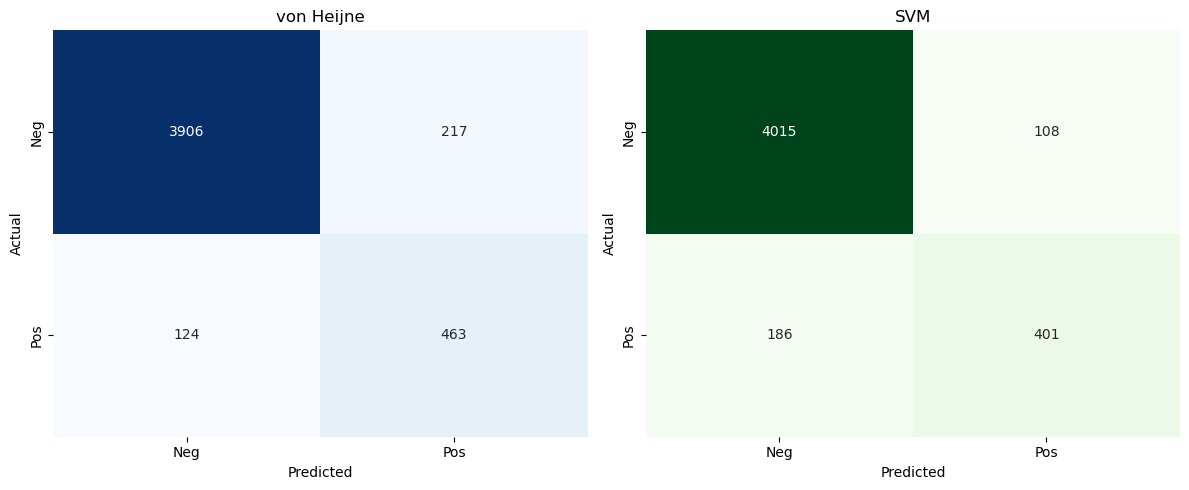

In [5]:
def get_metrics(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    acc = accuracy_score(y_true, y_pred)
    mcc = matthews_corrcoef(y_true, y_pred)
    sens = recall_score(y_true, y_pred) # Sensitivity = Recall
    ppv = precision_score(y_true, y_pred) # PPV = Precision
    return {"ACC": acc, "MCC": mcc, "Sens": sens, "PPV": ppv, "TP": tp, "TN": tn, "FP": fp, "FN": fn}

metrics_vh = get_metrics(df_bench['label'], df_bench['pred_vh'])
metrics_svm = get_metrics(df_bench['label'], df_bench['pred_svm'])

# Print comparison table
results = pd.DataFrame([metrics_vh, metrics_svm], index=["von Heijne", "SVM"])
print("\nBenchmark Performance Metrics")
print(results[["ACC", "MCC", "Sens", "PPV"]].round(3))

print("\nConfusion Matrices")
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap([[metrics_vh['TN'], metrics_vh['FP']], [metrics_vh['FN'], metrics_vh['TP']]], 
            annot=True, fmt="d", cmap="Blues", ax=axes[0], cbar=False)
axes[0].set_title("von Heijne")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")
axes[0].set_xticklabels(["Neg", "Pos"]); axes[0].set_yticklabels(["Neg", "Pos"])

sns.heatmap([[metrics_svm['TN'], metrics_svm['FP']], [metrics_svm['FN'], metrics_svm['TP']]], 
            annot=True, fmt="d", cmap="Greens", ax=axes[1], cbar=False)
axes[1].set_title("SVM")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Actual")
axes[1].set_xticklabels(["Neg", "Pos"]); axes[1].set_yticklabels(["Neg", "Pos"])

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "eval_confusion_matrix_comparison.png"))
plt.show()

## 6. False Positive Analysis – Transmembrane Helix

False Positive Analysis: TM Helix Interference
Negative Benchmark Total: 4123
von Heijne FPs: 217
  -> Among them, containing TM helix: 118 (54.4%)
SVM FPs: 108
  -> Among them, containing TM helix: 44 (40.7%)


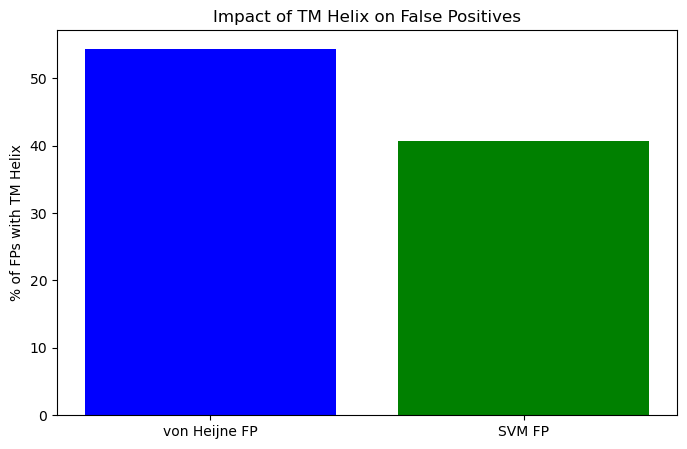

In [6]:
print("False Positive Analysis: TM Helix Interference")

# Filter negative samples (true label = 0)
df_neg_bench = df_bench[df_bench['label'] == 0].copy()

if 'tm_helix_start_leq_90' in df_neg_bench.columns:
    # Identify false positives (FPs) from von Heijne
    fp_vh = df_neg_bench[df_neg_bench['pred_vh'] == 1]
    tm_in_fp_vh = fp_vh['tm_helix_start_leq_90'].sum()
    # Identify false positives (FPs) from SVM
    fp_svm = df_neg_bench[df_neg_bench['pred_svm'] == 1]
    tm_in_fp_svm = fp_svm['tm_helix_start_leq_90'].sum()
    
    print(f"Negative Benchmark Total: {len(df_neg_bench)}")
    print(f"von Heijne FPs: {len(fp_vh)}")
    print(f"  -> Among them, containing TM helix: {tm_in_fp_vh} ({tm_in_fp_vh/len(fp_vh)*100:.1f}%)")
    print(f"SVM FPs: {len(fp_svm)}")
    print(f"  -> Among them, containing TM helix: {tm_in_fp_svm} ({tm_in_fp_svm/len(fp_svm)*100:.1f}%)")
    
    # Plot comparison
    plt.figure(figsize=(8, 5))
    plt.bar(["von Heijne FP", "SVM FP"], 
            [tm_in_fp_vh/len(fp_vh)*100, tm_in_fp_svm/len(fp_svm)*100], color=['blue', 'green'])
    plt.ylabel("% of FPs with TM Helix")
    plt.title("Impact of TM Helix on False Positives")
    plt.savefig(os.path.join(FIGURES_DIR, "eval_fp_tm_analysis.png"))
    plt.show()
else:
    print("Warning: 'tm_helix_start_leq_90' column not found in Benchmark data.")

## 7. False Negative Analysis – Sequence Logo

False Negative Analysis: Generating Logo for von Heijne FNs
Found 124 False Negatives from von Heijne.
FN Motifs saved to: C:\Users\b1795\Desktop\Laboratory2_SP\data_processed\vonheijne_FN_motifs.fasta
Manually use the WebLogo online tool to generate a sequence logo of signal peptide cleavage sites for false negative samples (Sequence Logo of SP cleavage sites for von Heijne False Negatives)
Displaying False Negative Sequence Logo


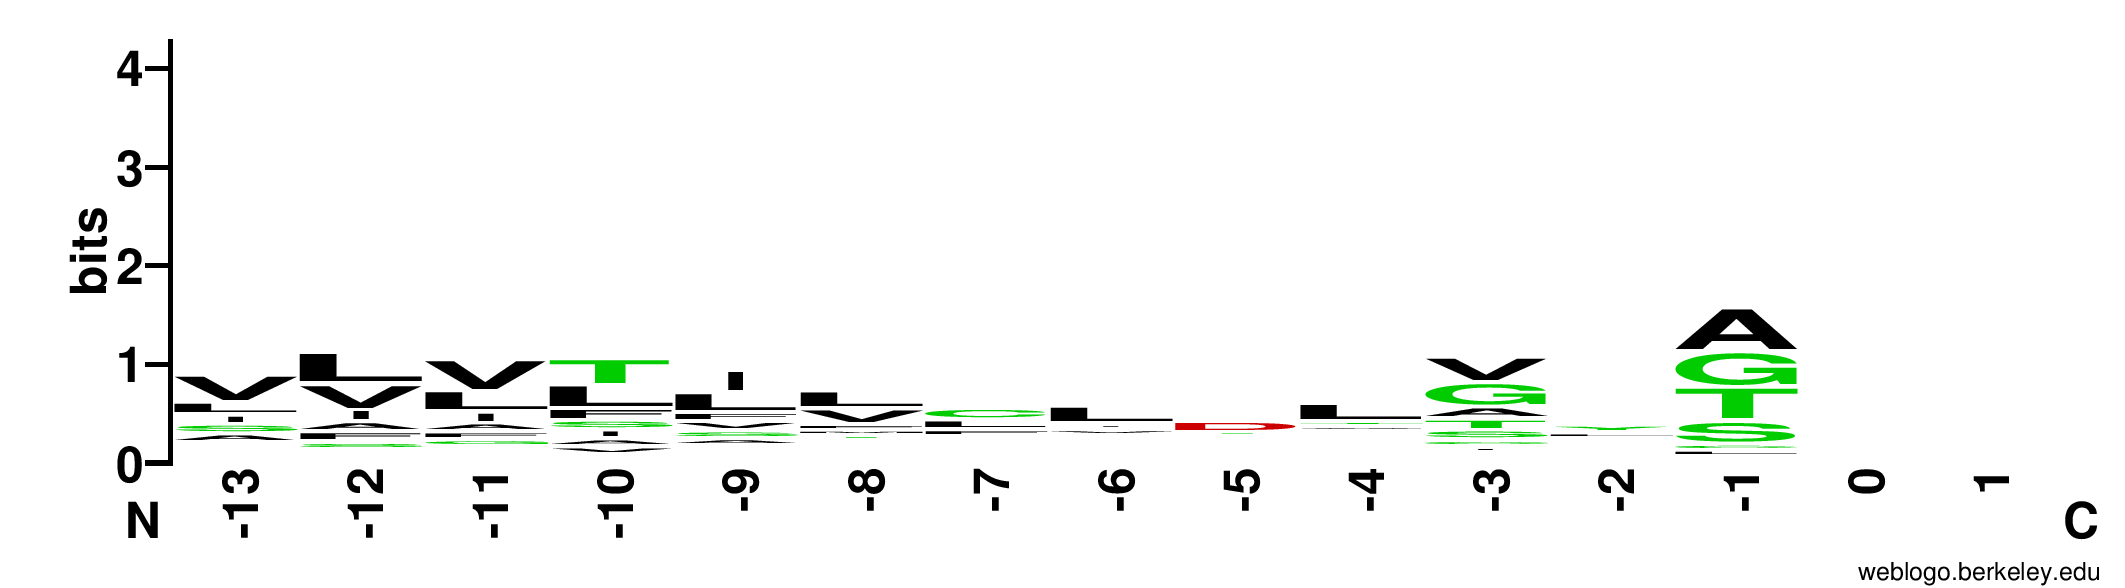

Although FN samples retain partial cleavage site features at positions (-3, -1), their hydrophobic core region (-13 to -6) shows very weak signal and lacks typical hydrophobic amino acid enrichment.
This explains why the von Heijne model produces false negatives.


In [13]:
print("False Negative Analysis: Generating Logo for von Heijne FNs")

# Identify false negatives (FN) from von Heijne
df_fn_vh = df_bench[(df_bench['label'] == 1) & (df_bench['pred_vh'] == 0)]
print(f"Found {len(df_fn_vh)} False Negatives from von Heijne.")

# Extract cleavage site windows
fn_windows = []
for _, row in df_fn_vh.iterrows():
    acc = row['accession']
    site = int(row['sp_cleavage_site'])
    if acc in seq_dict:
        seq = str(seq_dict[acc])
        # Compute slice indices
        start_idx = site - 13; end_idx = site + 2
        # Ensure indices are within bounds
        if start_idx >= 0 and end_idx <= len(seq):
            fn_windows.append(seq[start_idx:end_idx])

# Save FASTA
FN_LOGO_FASTA = os.path.join(DATA_PROCESSED_DIR, "vonheijne_FN_motifs.fasta")
with open(FN_LOGO_FASTA, "w") as f:
    for i, s in enumerate(fn_windows):
        f.write(f">fn_{i}\n{s}\n")

print(f"FN Motifs saved to: {FN_LOGO_FASTA}")
print("Manually use the WebLogo online tool to generate a sequence logo of signal peptide cleavage sites for false negative samples (Sequence Logo of SP cleavage sites for von Heijne False Negatives)")

# Display result image
FN_LOGO_PNG = os.path.join(FIGURES_DIR, "vonheijne_fn_logo.png")

if os.path.exists(FN_LOGO_PNG):
    print("Displaying False Negative Sequence Logo")
    display(Image(filename=FN_LOGO_PNG, width=800))
    print("Although FN samples retain partial cleavage site features at positions (-3, -1), their hydrophobic core region (-13 to -6) shows very weak signal and lacks typical hydrophobic amino acid enrichment.")
    print("This explains why the von Heijne model produces false negatives.")
else:
    print(f"\n[Pending] Image not found at: {FN_LOGO_PNG}")